# MCP BERT Fake News Detection - Server Implementation

- **Status:** PRODUCTION READY
- **Model:** BERT (bert-base-uncased)
- **Accuracy:** 84.74% on unseen data (64,951 articles)

This notebook demonstrates the complete MCP server implementation with visualization and interactive examples.

---

## Part 1: Setup & Imports

In [2]:
# Import required libraries
import sys
import json
import time
from pathlib import Path
from typing import Dict, List, Any

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import BERT utilities
import bert_utils

## Part 2: Load BERT Model & Initialize Server

In [4]:
model, tokenizer = bert_utils.load_model('models/bert_fake_news')


INFO:bert_utils:MacBook GPU (MPS) detected
INFO:bert_utils:Model loaded from models/bert_fake_news


## Part 3: MCP Server Class Implementation

The complete BERTMCPServer class is now available in a separate production-ready module: **mcp_server_class.py**

This file contains:
- Full BERTMCPServer class with all API methods
- Comprehensive docstrings and examples
- Type hints for better code quality
- Clean separation of concerns

Import and initialize the server below:

In [6]:

from mcp_server_class import BERTMCPServer

server = BERTMCPServer(model, tokenizer, model_id="bert_fake_news")

## Part 4: Server API Demonstrations

In [8]:


models = server.list_models()
for model in models:
    print(f"\nModel: {model['id']}")
    print(f"   Type: {model['type']}")
    print(f"   Accuracy: {model['accuracy']*100:.2f}%")
    print(f"   Version: {model['version']}")


Model: bert_fake_news
   Type: bert-fake-news-detector
   Accuracy: 84.74%
   Version: 1.0


In [10]:
info = server.get_model_info()

print(f"\nModel Information:")
print(f"  ID: {info['id']}")
print(f"  Type: {info['type']}")
print(f"  Model: {info['model_type']}")
print(f"  Parameters: {info['parameters']:,}")

print(f"\nPerformance Metrics:")
print(f"  Training Accuracy: {info['training_accuracy']*100:.2f}%")
print(f"  Unseen Data Accuracy: {info['unseen_accuracy']*100:.2f}%")
print(f"  Precision: {info['precision']*100:.2f}%")
print(f"  Recall: {info['recall']*100:.2f}%")
print(f"  F1 Score: {info['f1_score']:.4f}")
print(f"  ROC-AUC: {info['roc_auc']:.4f}")

print(f"\nTest Data:")
print(f"  Training Test Samples: {info['test_samples']:,}")
print(f"  Unseen Test Samples: {info['unseen_samples']:,}")
print(f"  GPU Acceleration: {'Yes' if info['gpu_acceleration'] else 'No'}")


Model Information:
  ID: bert_fake_news
  Type: bert-fake-news-detector
  Model: bert-base-uncased
  Parameters: 110,000,000

Performance Metrics:
  Training Accuracy: 99.91%
  Unseen Data Accuracy: 84.74%
  Precision: 82.13%
  Recall: 87.97%
  F1 Score: 0.8495
  ROC-AUC: 0.9360

Test Data:
  Training Test Samples: 6,734
  Unseen Test Samples: 64,951
  GPU Acceleration: Yes


In [12]:
print("SINGLE ARTICLE PREDICTION")

test_articles = [
    "Scientists announce major breakthrough in cancer research with new treatment",
    "Secret government technology being hidden from public EXPOSED!!!",
    "Economic recovery accelerates with new jobs report showing strong growth"
]

for i, article in enumerate(test_articles, 1):
    print(f"\n--- Article {i} ---")
    print(f"Text: {article[:70]}...")
    
    result = server.predict(article)
    
    if "error" not in result:
        pred = result["prediction"]
        emoji = "YES" if pred["class"] == "REAL" else "NO"
        print(f"Prediction: {emoji} {pred['class']}")
        print(f"Confidence: {pred['confidence_percent']} ({pred['confidence']:.4f})")
        print(f"Processing Time: {result['metadata']['processing_time_ms']}ms")
    else:
        print(f"Error: {result['error']}")

INFO:bert_utils:MacBook GPU (MPS) detected


SINGLE ARTICLE PREDICTION

--- Article 1 ---
Text: Scientists announce major breakthrough in cancer research with new tre...


INFO:bert_utils:MacBook GPU (MPS) detected
INFO:bert_utils:MacBook GPU (MPS) detected


Prediction: YES REAL
Confidence: 97.79% (0.9779)
Processing Time: 360.15ms

--- Article 2 ---
Text: Secret government technology being hidden from public EXPOSED!!!...
Prediction: NO FAKE
Confidence: 99.99% (0.9999)
Processing Time: 15.68ms

--- Article 3 ---
Text: Economic recovery accelerates with new jobs report showing strong grow...
Prediction: YES REAL
Confidence: 96.77% (0.9677)
Processing Time: 11.35ms


In [14]:
print("BATCH PREDICTIONS")

batch_articles = [
    "New vaccine shows promising results in clinical trials",
    "SHOCKING: Celebrity has secret alien connections",
    "Stock market reaches new high amid economic growth",
    "Famous actor admits to government mind control conspiracy",
    "Research team discovers new species in Amazon rainforest"
]

print(f"\nProcessing {len(batch_articles)} articles...")
results = server.predict_batch(batch_articles)

print(f"\nBatch Processing Complete:")
print(f"  Total: {results['total']} articles")
print(f"  Real: {results['real_count']} ({results['real_percent']})")
print(f"  Fake: {results['fake_count']} ({results['fake_percent']})")
print(f"  Avg Confidence: {results['avg_confidence']:.2%}")
print(f"  Processing Time: {results['metadata']['total_processing_time_s']}s")
print(f"  Time per Article: {results['metadata']['avg_time_per_article_ms']}ms")

INFO:bert_utils:MacBook GPU (MPS) detected
INFO:bert_utils:MacBook GPU (MPS) detected
INFO:bert_utils:MacBook GPU (MPS) detected
INFO:bert_utils:MacBook GPU (MPS) detected


BATCH PREDICTIONS

Processing 5 articles...


INFO:bert_utils:MacBook GPU (MPS) detected



Batch Processing Complete:
  Total: 5 articles
  Real: 3 (60.0%)
  Fake: 2 (40.0%)
  Avg Confidence: 99.10%
  Processing Time: 0.22s
  Time per Article: 43.26ms


In [16]:
print("Detailed Batch Results:")

batch_data = []
for pred in results['predictions']:
    batch_data.append({
        'Text': pred['text'][:50] + '...' if len(pred['text']) > 50 else pred['text'],
        'Prediction': pred['prediction']['class'],
        'Confidence': f"{pred['prediction']['confidence']:.2%}",
        'Processing (ms)': pred['metadata']['processing_time_ms']
    })

df_results = pd.DataFrame(batch_data)
print(df_results.to_string(index=False))

Detailed Batch Results:
                                                 Text Prediction Confidence  Processing (ms)
New vaccine shows promising results in clinical tr...       REAL     99.56%           170.43
     SHOCKING: Celebrity has secret alien connections       FAKE     99.99%            12.97
   Stock market reaches new high amid economic growth       REAL     96.15%            11.14
Famous actor admits to government mind control con...       FAKE     99.98%            10.88
Research team discovers new species in Amazon rain...       REAL     99.82%            10.73


In [18]:
print("SERVER STATISTICS")

stats = server.get_statistics()

print(f"\nPrediction Statistics:")
print(f"  Total Predictions: {stats['total_predictions']}")
print(f"  Real Predictions: {stats['real_predictions']}")
print(f"  Fake Predictions: {stats['fake_predictions']}")
print(f"  Avg Confidence: {stats['avg_confidence']:.2%}")
print(f"  Min Confidence: {stats['min_confidence']:.2%}")
print(f"  Max Confidence: {stats['max_confidence']:.2%}")

SERVER STATISTICS

Prediction Statistics:
  Total Predictions: 8
  Real Predictions: 5
  Fake Predictions: 3
  Avg Confidence: 98.75%
  Min Confidence: 96.15%
  Max Confidence: 99.99%


## Part 5: Visualization & Analytics

Generating visualizations...


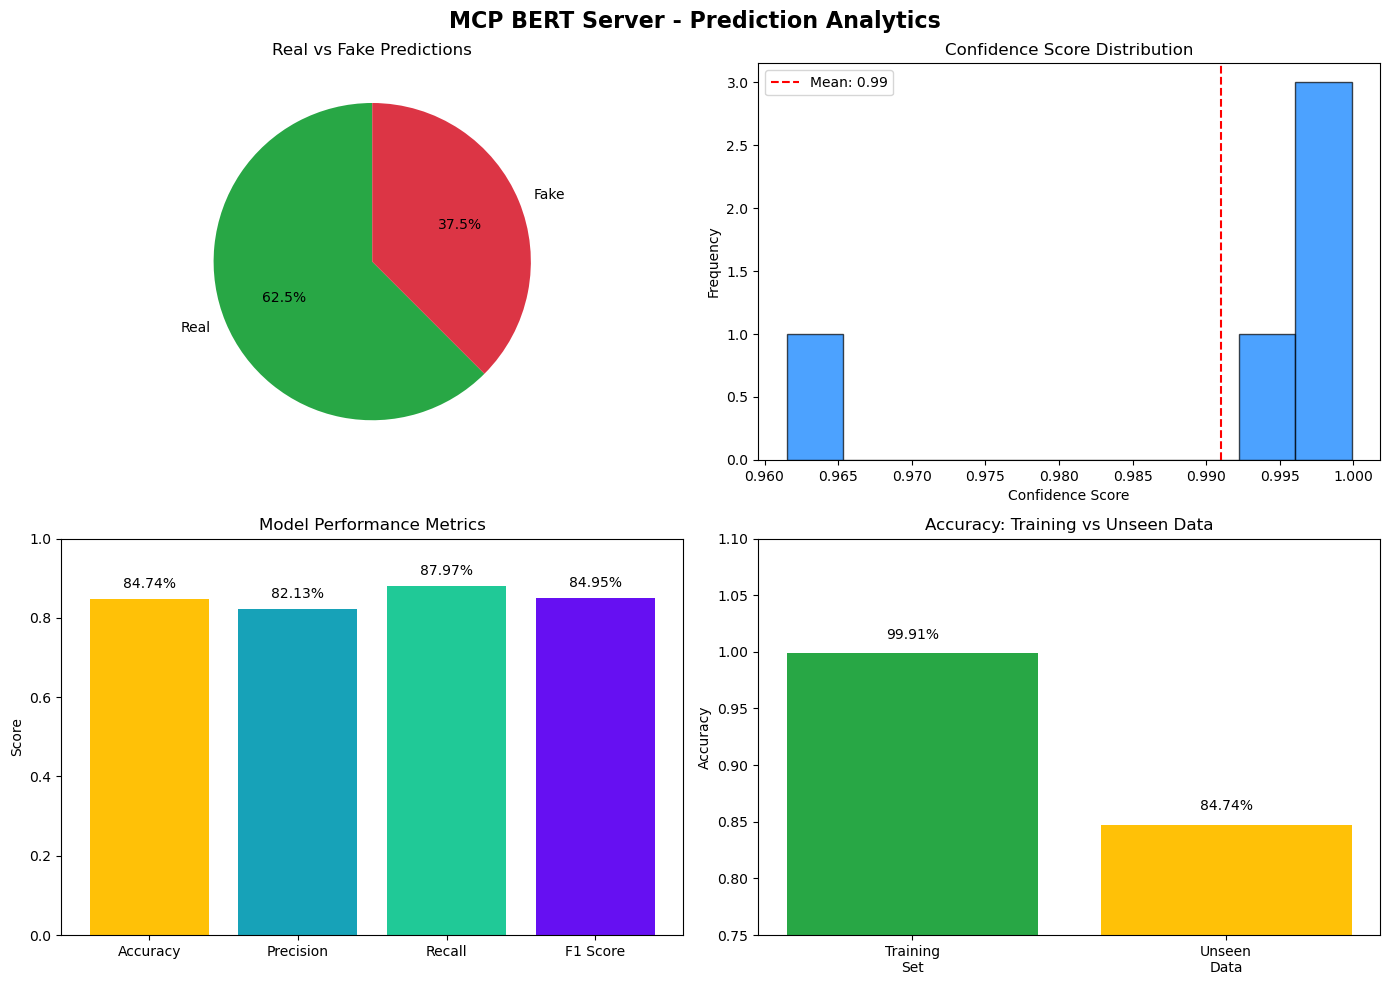

In [26]:
print("Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MCP BERT Server - Prediction Analytics', fontsize=16, fontweight='bold')

# Chart 1: Real vs Fake Count
ax1 = axes[0, 0]
labels = ['Real', 'Fake']
sizes = [stats['real_predictions'], stats['fake_predictions']]
colors = ['#28a745', '#dc3545']
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Real vs Fake Predictions')

# Chart 2: Confidence Distribution
ax2 = axes[0, 1]
confidences = [p["prediction"]["confidence"] for p in results['predictions']]
ax2.hist(confidences, bins=10, color='#007bff', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Frequency')
ax2.set_title('Confidence Score Distribution')
ax2.axvline(np.mean(confidences), color='red', linestyle='--', label=f'Mean: {np.mean(confidences):.2f}')
ax2.legend()

# Chart 3: Model Performance Metrics
ax3 = axes[1, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [
    info['unseen_accuracy'],
    info['precision'],
    info['recall'],
    info['f1_score']
]
bars = ax3.bar(metrics, values, color=['#ffc107', '#17a2b8', '#20c997', '#6610f2'])
ax3.set_ylabel('Score')
ax3.set_title('Model Performance Metrics')
ax3.set_ylim([0, 1])
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.2%}', ha='center', va='bottom')

# Chart 4: Model Comparison
ax4 = axes[1, 1]
datasets = ['Training\nSet', 'Unseen\nData']
accuracy = [info['training_accuracy'], info['unseen_accuracy']]
bars = ax4.bar(datasets, accuracy, color=['#28a745', '#ffc107'])
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy: Training vs Unseen Data')
ax4.set_ylim([0.75, 1.1])
for bar, val in zip(bars, accuracy):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Part 6: API Response Examples (JSON Format)

In [28]:
print("LIST MODELS - JSON Response")

response = server.list_models()
print(json.dumps(response, indent=2))

LIST MODELS - JSON Response
[
  {
    "id": "bert_fake_news",
    "type": "bert-fake-news-detector",
    "accuracy": 0.8474,
    "version": "1.0"
  }
]


In [30]:
print("MODEL INFO - JSON Response")

response = server.get_model_info()
subset = {
    "id": response["id"],
    "type": response["type"],
    "model_type": response["model_type"],
    "accuracy_metrics": {
        "training_accuracy": response["training_accuracy"],
        "unseen_accuracy": response["unseen_accuracy"],
        "precision": response["precision"],
        "recall": response["recall"],
        "f1_score": response["f1_score"],
        "roc_auc": response["roc_auc"]
    }
}
print(json.dumps(subset, indent=2))

MODEL INFO - JSON Response
{
  "id": "bert_fake_news",
  "type": "bert-fake-news-detector",
  "model_type": "bert-base-uncased",
  "accuracy_metrics": {
    "training_accuracy": 0.9991,
    "unseen_accuracy": 0.8474,
    "precision": 0.8213,
    "recall": 0.8797,
    "f1_score": 0.8495,
    "roc_auc": 0.936
  }
}


In [32]:
print("6.3: SINGLE PREDICTION - JSON Response")

test_text = "New study reveals benefits of regular exercise for health"
response = server.predict(test_text)
print(json.dumps(response, indent=2))

INFO:bert_utils:MacBook GPU (MPS) detected


6.3: SINGLE PREDICTION - JSON Response
{
  "model_id": "bert_fake_news",
  "text": "New study reveals benefits of regular exercise for health",
  "prediction": {
    "label": 1,
    "class": "REAL",
    "confidence": 0.9961345195770264,
    "confidence_percent": "99.61%"
  },
  "metadata": {
    "processing_time_ms": 226.0,
    "text_length": 57,
    "timestamp": 1765830852.192172
  }
}


In [34]:
print("BATCH PREDICTION - JSON Response (Summary)")

batch_summary = {
    "model_id": results["model_id"],
    "total": results["total"],
    "statistics": {
        "real_count": results["real_count"],
        "fake_count": results["fake_count"],
        "real_percent": results["real_percent"],
        "fake_percent": results["fake_percent"],
        "avg_confidence": results["avg_confidence"]
    },
    "processing": results["metadata"]
}
print(json.dumps(batch_summary, indent=2))

BATCH PREDICTION - JSON Response (Summary)
{
  "model_id": "bert_fake_news",
  "total": 5,
  "statistics": {
    "real_count": 3,
    "fake_count": 2,
    "real_percent": "60.0%",
    "fake_percent": "40.0%",
    "avg_confidence": 0.9909925341606141
  },
  "processing": {
    "total_processing_time_s": 0.22,
    "avg_time_per_article_ms": 43.26,
    "timestamp": 1765830723.803145
  }
}
